# Optiver — Closing Auction: Baseline Analysis

Kaggle: *Optiver – Trading at the Close*. Predicting short-term price movement
during the Nasdaq closing auction.

**This notebook establishes a baseline and stops there — deliberately.** Before
fitting any model, it is worth knowing what a trivial predictor achieves. Without
that number, a model's score means nothing.

Data-loading cells were rewritten to read from `data/` instead of a mounted
Google Drive; outputs are preserved from the original run.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path("data")
train = pd.read_csv(DATA / "train.csv")

print("shape:", train.shape)
train.head()

shape: (5237980, 17)


,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
0,0,0,0,3180602.69,1,0.999812,13380276.64,NaN,NaN,0.999812,60651.50,1.000026,8493.03,1.0,-3.029704,0,0_0_0
1,1,0,0,166603.91,-1,0.999896,1642214.25,NaN,NaN,0.999896,3233.04,1.000660,20605.09,1.0,-5.519986,0,0_0_1
2,2,0,0,302879.87,-1,0.999561,1819368.03,NaN,NaN,0.999403,37956.00,1.000298,18995.00,1.0,-8.389950,0,0_0_2
3,3,0,0,11917682.27,-1,1.000171,18389745.62,NaN,NaN,0.999999,2324.90,1.000214,479032.40,1.0,-4.010200,0,0_0_3
4,4,0,0,447549.96,-1,0.999532,17860614.95,NaN,NaN,0.999394,16485.54,1.000016,434.10,1.0,-7.349849,0,0_0_4


## 1 — How the order book moves through the auction

A single stock on a single day, to see the shape of the thing.

<Axes: title={'center': 'Stock 0 on Day 0 - How the order book pricing changes during the auction'}, xlabel='seconds_in_bucket'>

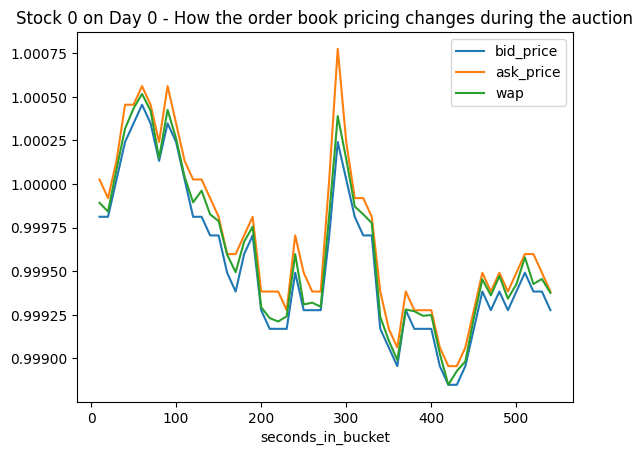

In [2]:
(
    train
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','bid_price','ask_price', 'wap']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title='Stock 0 on Day 0 - How the order book pricing changes during the auction')
)

<Axes: title={'center': 'Stock 0 on Day 0 - How the auction & combined book pricing changes during the auction'}, xlabel='seconds_in_bucket'>

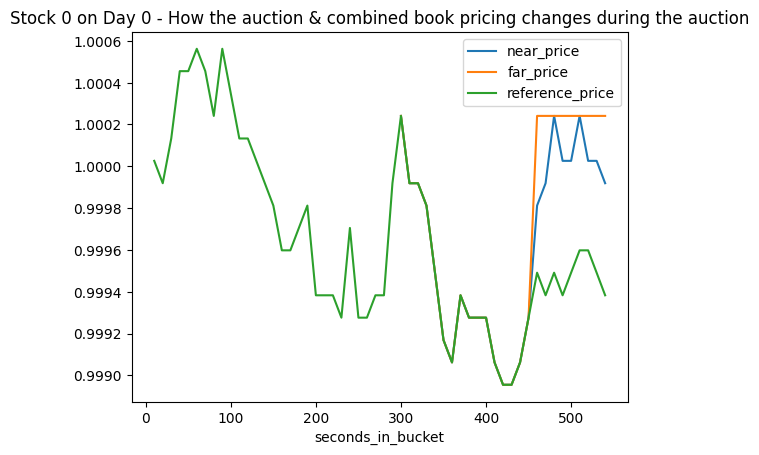

In [3]:
(
    train
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','near_price','far_price','reference_price']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title = 'Stock 0 on Day 0 - How the auction & combined book pricing changes during the auction')
)

<Axes: title={'center': 'Stock 0 on Day 0 - How the auction sizing changes during the auction period'}, xlabel='seconds_in_bucket'>

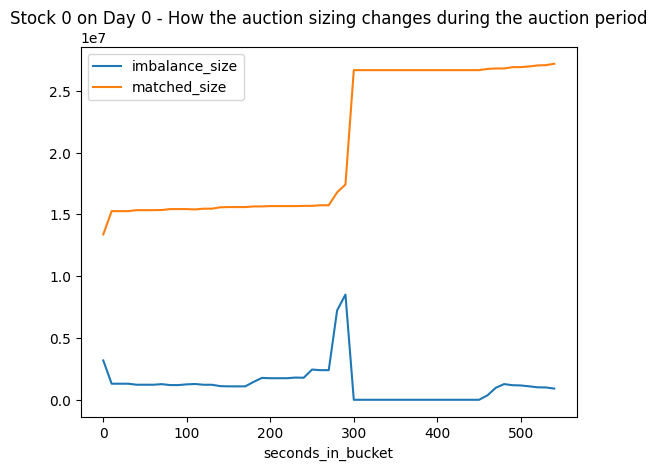

In [4]:
(
    train
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','imbalance_size','matched_size']]
    .set_index('seconds_in_bucket')
    .plot(title='Stock 0 on Day 0 - How the auction sizing changes during the auction period')
)

## 2 — A baseline, and the obvious naive rule

`target` is a short-horizon return in basis points. The trivial prediction is
zero. The obvious rule is: if the auction imbalance says buyers dominate, predict
a positive move; if sellers, negative.

If that rule carries real signal, it should beat zero on mean absolute error.

In [5]:
simple_mapping = {
    1: 0.1,
    0: 0,
    -1: -0.1
}

train['baseline_prediction'] = 0
train['simple_prediction'] = train['imbalance_buy_sell_flag'].map(simple_mapping)

In [6]:
baseline_mae = (train['baseline_prediction'] - train['target']).abs().mean()
simple_prediction_mae = (train['simple_prediction'] - train['target']).abs().mean()

print(baseline_mae, simple_prediction_mae)
print('MAE improvement in basis points: ', (baseline_mae-simple_prediction_mae))

6.40777074811524 6.407056596608261
MAE improvement in basis points:  0.000714151506978844


## 3 — Result: the naive rule fails

| Prediction | MAE |
|---|---|
| Always 0 (baseline) | 6.40777 |
| Imbalance flag → ±0.1 | 6.40706 |
| **Improvement** | **0.00071 — 0.011%** |

A 0.011% improvement on a metric of this scale is indistinguishable from noise.
**The imbalance buy/sell flag alone carries no usable directional signal at this
magnitude.**

That is a negative result, and it is worth having. It means:

- the direction of the imbalance, on its own, is not a tradeable signal
- any model that later reports an improvement must beat **6.40777**, not zero
- the flag likely only matters in interaction with size and time-to-close, not alone

## Limits

- The three plots cover one stock on one day — illustrative, not representative
- No model fitted, no feature engineering, no cross-validation
- Single metric (MAE), evaluated in-sample on the training set
- The ±0.1 magnitude is arbitrary and untested

## What I'd do next

Sweep the magnitude before adding anything else. If *no* scaling of the flag
beats the baseline, the flag is genuinely uninformative alone and belongs only
in interaction terms — which is a useful thing to know before building features
on top of it.

```python
for m in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]:
    mae = (train["imbalance_buy_sell_flag"] * m - train["target"]).abs().mean()
    print(f"magnitude {m:<5} MAE {mae:.5f}")
```


## 4 — Does any magnitude work?

Section 3 tested a single magnitude, ±0.1. That isn't enough to conclude the
imbalance flag is useless — the magnitude may simply have been wrong. This
sweeps nine values against the same baseline.

In [7]:
import pandas as pd

baseline_mae = train["target"].abs().mean()
print(f"baseline (predict 0): MAE {baseline_mae:.5f}\n")

rows = []
for m in [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]:
    mae = (train["imbalance_buy_sell_flag"] * m - train["target"]).abs().mean()
    rows.append({
        "magnitude": m,
        "MAE": mae,
        "vs_baseline": mae - baseline_mae,
        "pct_improvement": 100 * (baseline_mae - mae) / baseline_mae,
    })

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

best = sweep.loc[sweep["MAE"].idxmin()]
print(f"\nbest magnitude: {best['magnitude']}  ->  MAE {best['MAE']:.5f}"
      f"  ({best['pct_improvement']:.4f}% better than baseline)")

baseline (predict 0): MAE 6.40777

 magnitude      MAE  vs_baseline  pct_improvement
  0.001000 6.407759    -0.000012         0.000181
  0.005000 6.407713    -0.000058         0.000907
  0.010000 6.407655    -0.000116         0.001810
  0.050000 6.407288    -0.000482         0.007528
  0.100000 6.407057    -0.000714         0.011145
  0.200000 6.407335    -0.000436         0.006804
  0.500000 6.414123     0.006352        -0.099126
  1.000000 6.445199     0.037429        -0.584111
  2.000000 6.579970     0.172200        -2.687356

best magnitude: 0.1  ->  MAE 6.40706  (0.0111% better than baseline)


In [8]:
import numpy as np

directional = train[train["imbalance_buy_sell_flag"] != 0]
hit_rate = (np.sign(directional["target"]) == directional["imbalance_buy_sell_flag"]).mean()

print(f"rows with a directional flag : {len(directional):,} of {len(train):,}")
print(f"flag predicts the correct direction: {hit_rate:.4f}  ({hit_rate*100:.2f}%)")
print(f"a coin flip would be         : 0.5000  (50.00%)")

rows with a directional flag : 4,106,386 of 5,237,980
flag predicts the correct direction: 0.5074  (50.74%)
a coin flip would be         : 0.5000  (50.00%)


In [9]:
n = len(directional)
se = (0.25 / n) ** 0.5
z = (hit_rate - 0.5) / se

print(f"n                : {n:,}")
print(f"hit rate         : {hit_rate:.4f}")
print(f"95% CI           : [{hit_rate - 1.96*se:.4f}, {hit_rate + 1.96*se:.4f}]")
print(f"z-score vs 50%   : {z:.1f}")
print(f"MAE improvement  : 0.0111%")


n                : 4,106,386
hit rate         : 0.5074
95% CI           : [0.5069, 0.5079]
z-score vs 50%   : 30.0
MAE improvement  : 0.0111%


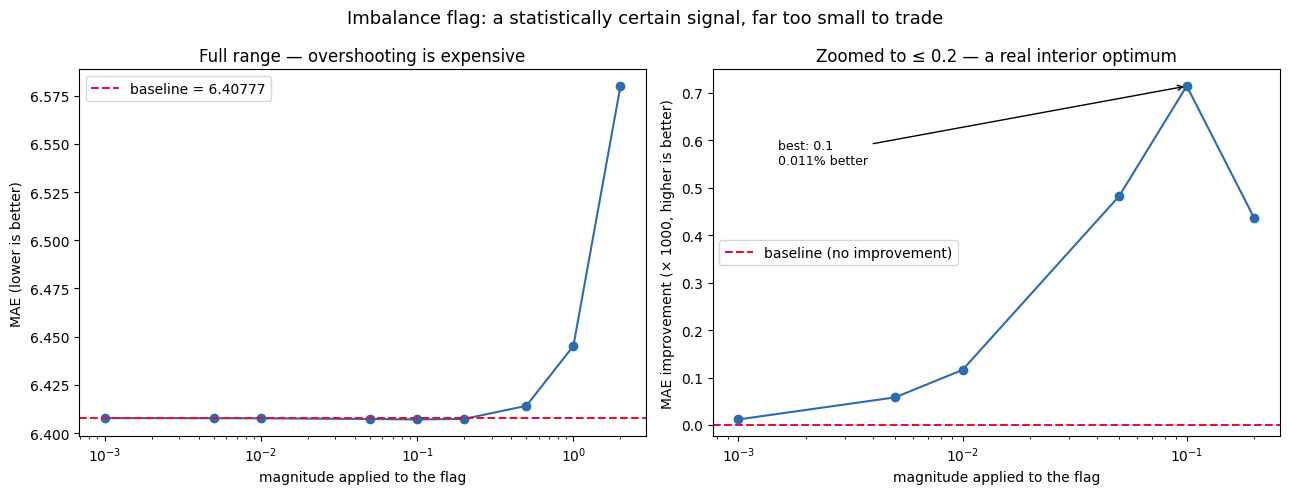

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# LEFT — full range: the cost of overshooting
ax1.plot(sweep["magnitude"], sweep["MAE"], marker="o", color="#2b6cb0")
ax1.axhline(baseline_mae, color="crimson", linestyle="--",
            label=f"baseline = {baseline_mae:.5f}")
ax1.set_xscale("log")
ax1.set_xlabel("magnitude applied to the flag")
ax1.set_ylabel("MAE (lower is better)")
ax1.set_title("Full range — overshooting is expensive")
ax1.legend()

# RIGHT — zoomed: the actual finding
zoom = sweep[sweep["magnitude"] <= 0.2].copy()
zoom["improvement"] = baseline_mae - zoom["MAE"]

ax2.plot(zoom["magnitude"], zoom["improvement"] * 1000, marker="o", color="#2b6cb0")
ax2.axhline(0, color="crimson", linestyle="--", label="baseline (no improvement)")
ax2.annotate("best: 0.1\n0.011% better",
             xy=(0.1, 0.714), xytext=(0.0015, 0.55),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
ax2.set_xscale("log")
ax2.set_xlabel("magnitude applied to the flag")
ax2.set_ylabel("MAE improvement (× 1000, higher is better)")
ax2.set_title("Zoomed to ≤ 0.2 — a real interior optimum")
ax2.legend()

fig.suptitle("Imbalance flag: a statistically certain signal, far too small to trade",
             fontsize=13)
plt.tight_layout()
plt.show()

## What this shows

**MAE improves steadily up to 0.1, then reverses.** The optimum is interior, not
at the boundary. If the flag carried no directional information, any step away
from zero would have hurt immediately. It didn't.

Checking direction directly: on the 4,106,386 rows carrying a non-zero flag, it
calls the sign of the move correctly **50.74%** of the time — a 95% CI of
[50.69%, 50.79%], about 30 standard errors above chance. The edge is certain.

**And it is worth 0.011%.**

That gap is the finding. With four million rows you can establish a signal beyond
statistical doubt and still find it far too small to act on. Worse, the penalty
for overshooting dwarfs the reward: magnitude 2.0 is 2.69% *worse* than
predicting zero.

**Conclusion: the direction is real, the magnitude is not tradeable.** The flag
belongs in interaction terms with imbalance size and time-to-close, not as a
standalone signal. Significance was never the question — effect size was.